### Length

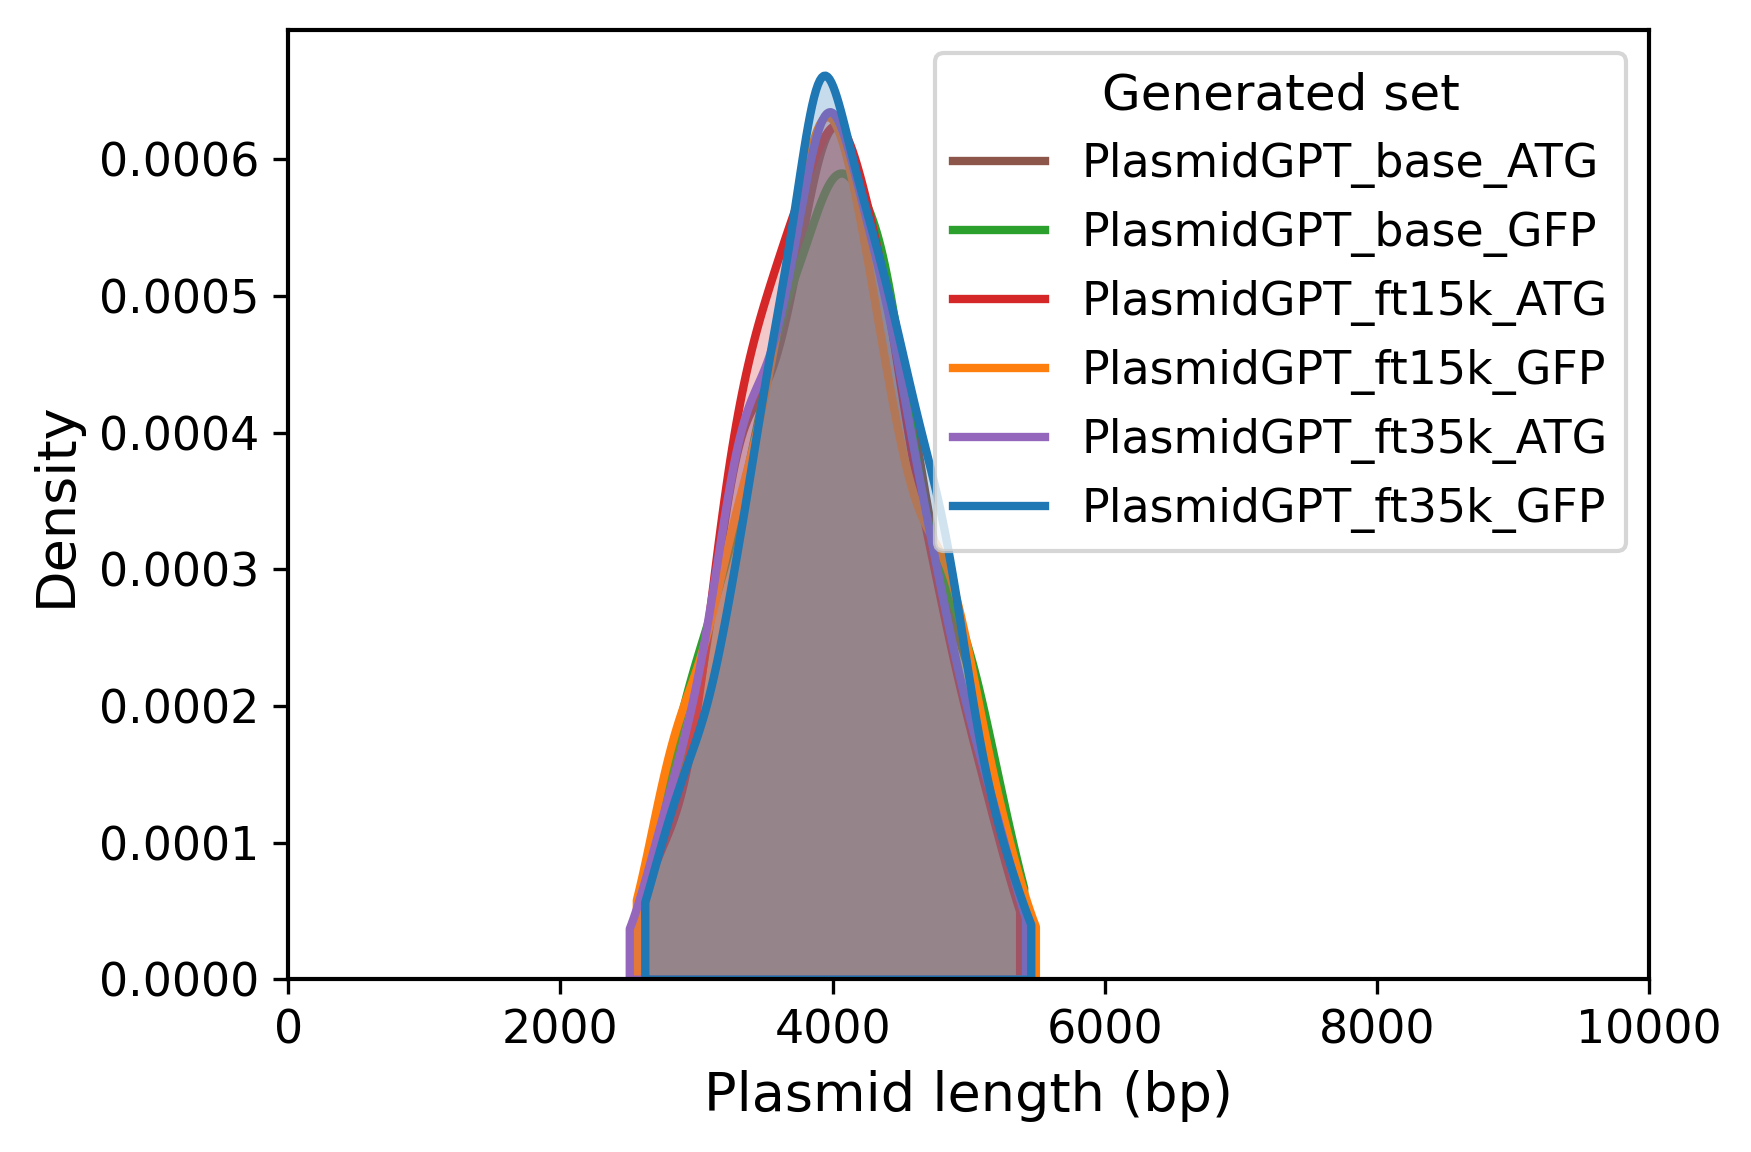

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ── Files ──
gen_files = {
    "PlasmidGPT_base_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_base_atg_generated_metadata.csv",
    "PlasmidGPT_base_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_basegfp2_generated_metadata.csv",
    "PlasmidGPT_ft15k_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15_atg_generated_metadata.csv",
    "PlasmidGPT_ft15k_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15kgfp_p_generated_metadata.csv",
    "PlasmidGPT_ft35k_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35_atg_generated_metadata.csv",
    "PlasmidGPT_ft35k_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35kgfp3_generated_metadata.csv",
}
order = list(gen_files.keys())
palette = {
    "PlasmidGPT_base_ATG": "#8c564b",
    "PlasmidGPT_base_GFP": "#2ca02c",
    "PlasmidGPT_ft15k_ATG": "#d62728",
    "PlasmidGPT_ft15k_GFP": "#ff7f0e",
    "PlasmidGPT_ft35k_ATG": "#9467bd",
    "PlasmidGPT_ft35k_GFP": "#1f77b4",
}

# Load
dfs = []
for name, path in gen_files.items():
    df = pd.read_csv(path)
    df["dataset"] = name
    dfs.append(df[["length_bp", "dataset"]])
gen_all = pd.concat(dfs, ignore_index=True).dropna(subset=["length_bp"])

# Style
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})

# Plot each line explicitly (so we control labels)
fig, ax = plt.subplots(figsize=(6, 4))
for name in order:
    sub = gen_all[gen_all["dataset"] == name]
    if len(sub):
        sns.kdeplot(
            data=sub, x="length_bp",
            lw=2, fill=True, alpha=0.25,
            clip=(0, 100000), cut=0,
            color=palette[name], ax=ax
        )

ax.set_xlabel("Plasmid length (bp)")
ax.set_ylabel("Density")
ax.set_xlim(0, 10000)

# Build a guaranteed legend
handles = [Line2D([0], [0], color=palette[n], lw=2) for n in order]
ax.legend(handles, order, title="Generated set", loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


In [5]:
from pathlib import Path
# save vector pdf
OUT = Path("figures"); OUT.mkdir(exist_ok=True, parents=True)
fig.savefig(OUT/"length_generated.pdf", bbox_inches="tight")
plt.close(fig)

### GFP

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np

# ─── File paths ───────────────────────────────────────────────
ADDGENE = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/addgene_plasmid_metadata.csv"
FT25    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pbd_ft25.tsv"
FT15    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/ecoli_pdb_ft15.tsv"
FT35    = "/cs/student/projects1/aibh/2024/acunning/Projects/Data/metadata/ft_metadata/Ecoli_pdb_ft35.tsv"

def _read(path):
    return pd.read_csv(path) if path.endswith(".csv") else pd.read_csv(path, sep="\t")

def _find_gc_col(df):
    # look for any column mentioning 'gc' (case-insensitive)
    candidates = [c for c in df.columns if "gc" in c.lower()]
    return candidates[0] if candidates else None

def _to_gc_percent(series):
    s = pd.to_numeric(series, errors="coerce")
    if s.max() is None or np.isnan(s.max()):
        return s
    return s*100.0 if s.max() <= 1.0 else s

def load_with_addgene(main_file, addgene_file, name):
    main = _read(main_file)
    addg = _read(addgene_file)

    # unify length
    if "Size (bp)" not in main.columns:
        raise KeyError(f"'Size (bp)' not found in {main_file}. Found: {list(main.columns)}")
    if "Size (bp)" not in addg.columns:
        raise KeyError(f"'Size (bp)' not found in {addgene_file}. Found: {list(addg.columns)}")

    main["length_bp"] = pd.to_numeric(main["Size (bp)"], errors="coerce")
    addg["length_bp"] = pd.to_numeric(addg["Size (bp)"], errors="coerce")

    # detect & convert GC → percent
    gc_col_main = _find_gc_col(main); gc_col_addg = _find_gc_col(addg)
    main["gc_percent"] = _to_gc_percent(main[gc_col_main]) if gc_col_main else np.nan
    addg["gc_percent"] = _to_gc_percent(addg[gc_col_addg]) if gc_col_addg else np.nan

    df = pd.concat([main[["length_bp","gc_percent"]], addg[["length_bp","gc_percent"]]], ignore_index=True)
    df["dataset"] = name
    return df

df25 = load_with_addgene(FT25, ADDGENE, "PlasmidGPT_ft25k_train")
df15 = load_with_addgene(FT15, ADDGENE, "PlasmidGPT_ft15k_train")
df35 = load_with_addgene(FT35, ADDGENE, "PlasmidGPT_ft35k_train")

train_all = pd.concat([df15, df25, df35], ignore_index=True)
train_all = train_all.dropna(subset=["gc_percent"])
train_all = train_all[(train_all["gc_percent"] >= 0) & (train_all["gc_percent"] <= 100)]


In [7]:
GEN_FILES = {
    "PlasmidGPT_base_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_base_atg_generated_metadata.csv",
    "PlasmidGPT_base_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_basegfp2_generated_metadata.csv",
    "PlasmidGPT_ft15k_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15_atg_generated_metadata.csv",
    "PlasmidGPT_ft15k_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft15kgfp_p_generated_metadata.csv",
    "PlasmidGPT_ft35k_ATG": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35_atg_generated_metadata.csv",
    "PlasmidGPT_ft35k_GFP": "/cs/student/projects1/aibh/2024/acunning/Projects/Results/generated_seqs/gen_ft35kgfp3_generated_metadata.csv",
}

gen_list = []
for name, path in GEN_FILES.items():
    g = pd.read_csv(path)
    g["dataset"] = name
    gen_list.append(g[["gc_percent","dataset"]])
gen_all = pd.concat(gen_list, ignore_index=True).dropna(subset=["gc_percent"])


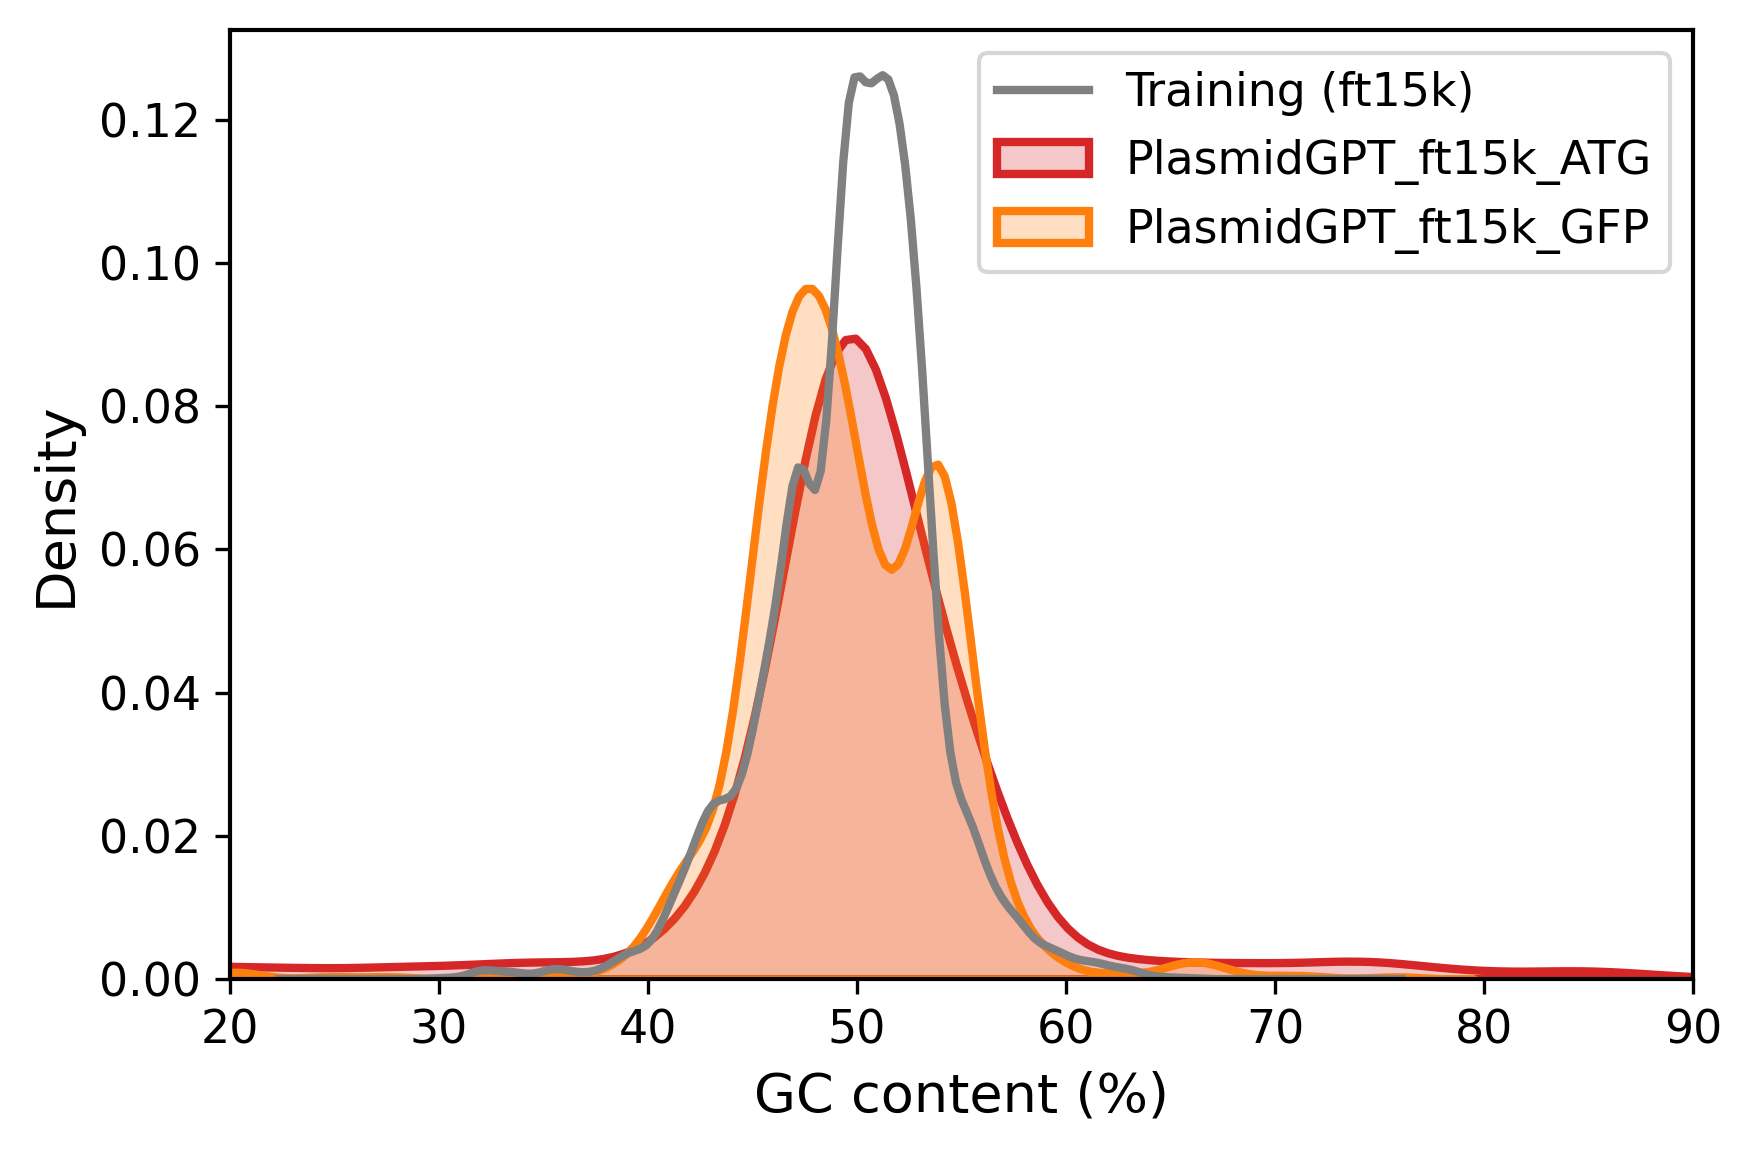

In [19]:
plt.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 12, "axes.labelsize": 13, "axes.titlesize": 13,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "figure.dpi": 300
})
palette = {
    "PlasmidGPT_ft15k_ATG": "#d62728",  # red
    "PlasmidGPT_ft15k_GFP": "#ff7f0e",  # orange
    "PlasmidGPT_ft35k_ATG": "#9467bd",  # purple
    "PlasmidGPT_ft35k_GFP": "#1f77b4",  # blue
    "PlasmidGPT_base_ATG":  "#8c564b",  # brown
    "PlasmidGPT_base_GFP":  "#2ca02c",  # green
}

fig, ax = plt.subplots(figsize=(6,4))
# training (grey)
sns.kdeplot(
    data=train_all[train_all["dataset"]=="PlasmidGPT_ft15k_train"],
    x="gc_percent", color="grey", lw=2, label="Training (ft15k)", ax=ax
)
# generated (ATG + GFP)
for name in ["PlasmidGPT_ft15k_ATG","PlasmidGPT_ft15k_GFP"]:
    sns.kdeplot(
        data=gen_all[gen_all["dataset"]==name],
        x="gc_percent", lw=2, fill=True, alpha=0.25,
        color=palette[name], label=name, ax=ax
    )
ax.set_xlabel("GC content (%)"); ax.set_ylabel("Density")
ax.set_xlim(20,90); ax.legend(loc="upper right", frameon=True)
fig.tight_layout(); plt.show()
# Optional save:
# from pathlib import Path; Path("figures").mkdir(exist_ok=True, parents=True)
# fig.savefig("figures/gc_ft15k_vs_training.pdf", bbox_inches="tight")


In [20]:
# Optional save:
from pathlib import Path; Path("figures").mkdir(exist_ok=True, parents=True)
fig.savefig("figures/gc_ft15k_vs_training.pdf", bbox_inches="tight")

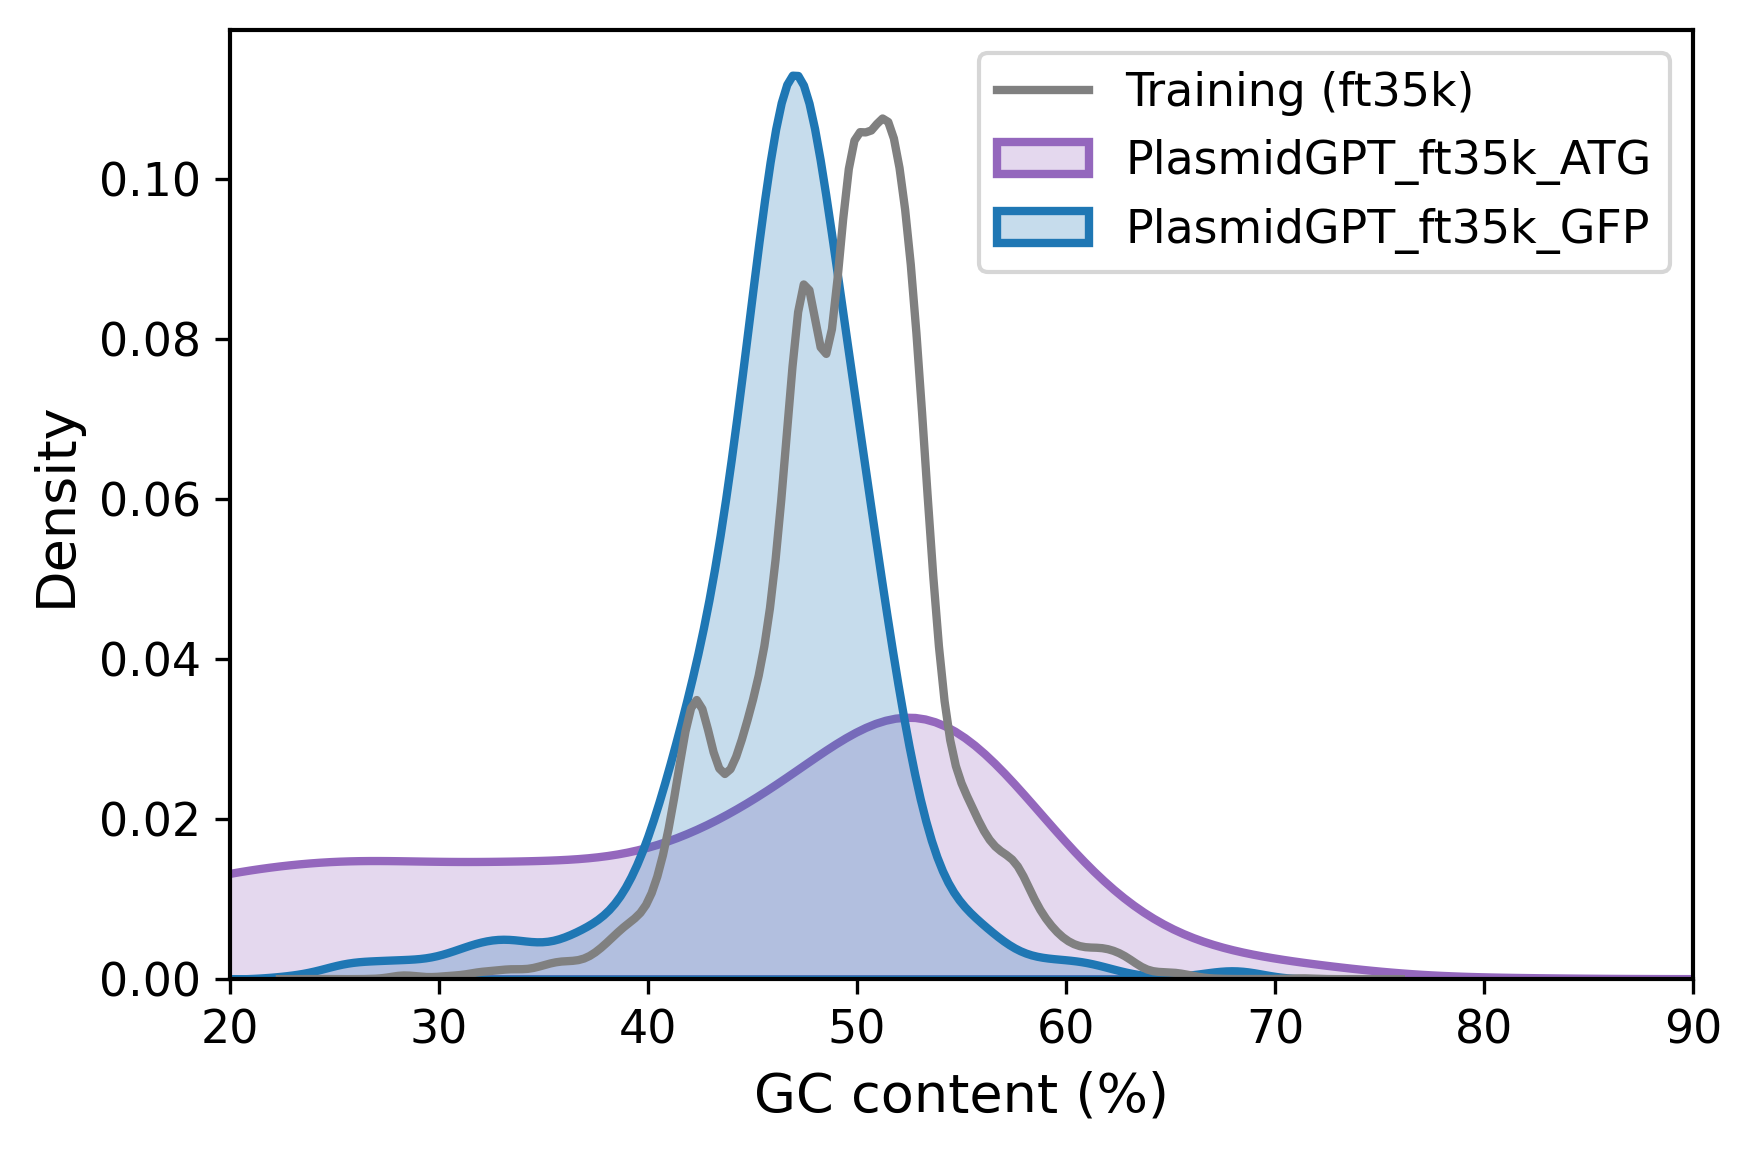

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(
    data=train_all[train_all["dataset"]=="PlasmidGPT_ft35k_train"],
    x="gc_percent", color="grey", lw=2, label="Training (ft35k)", ax=ax
)
for name in ["PlasmidGPT_ft35k_ATG","PlasmidGPT_ft35k_GFP"]:
    sns.kdeplot(
        data=gen_all[gen_all["dataset"]==name],
        x="gc_percent", lw=2, fill=True, alpha=0.25,
        color=palette[name], label=name, ax=ax
    )
ax.set_xlabel("GC content (%)"); ax.set_ylabel("Density")
ax.set_xlim(20,90); ax.legend(loc="upper right", frameon=True)
fig.tight_layout(); plt.show()
# Optional:
# fig.savefig("figures/gc_ft35k_vs_training.pdf", bbox_inches="tight")


In [18]:
fig.savefig("figures/gc_ft35k_vs_training.pdf", bbox_inches="tight")

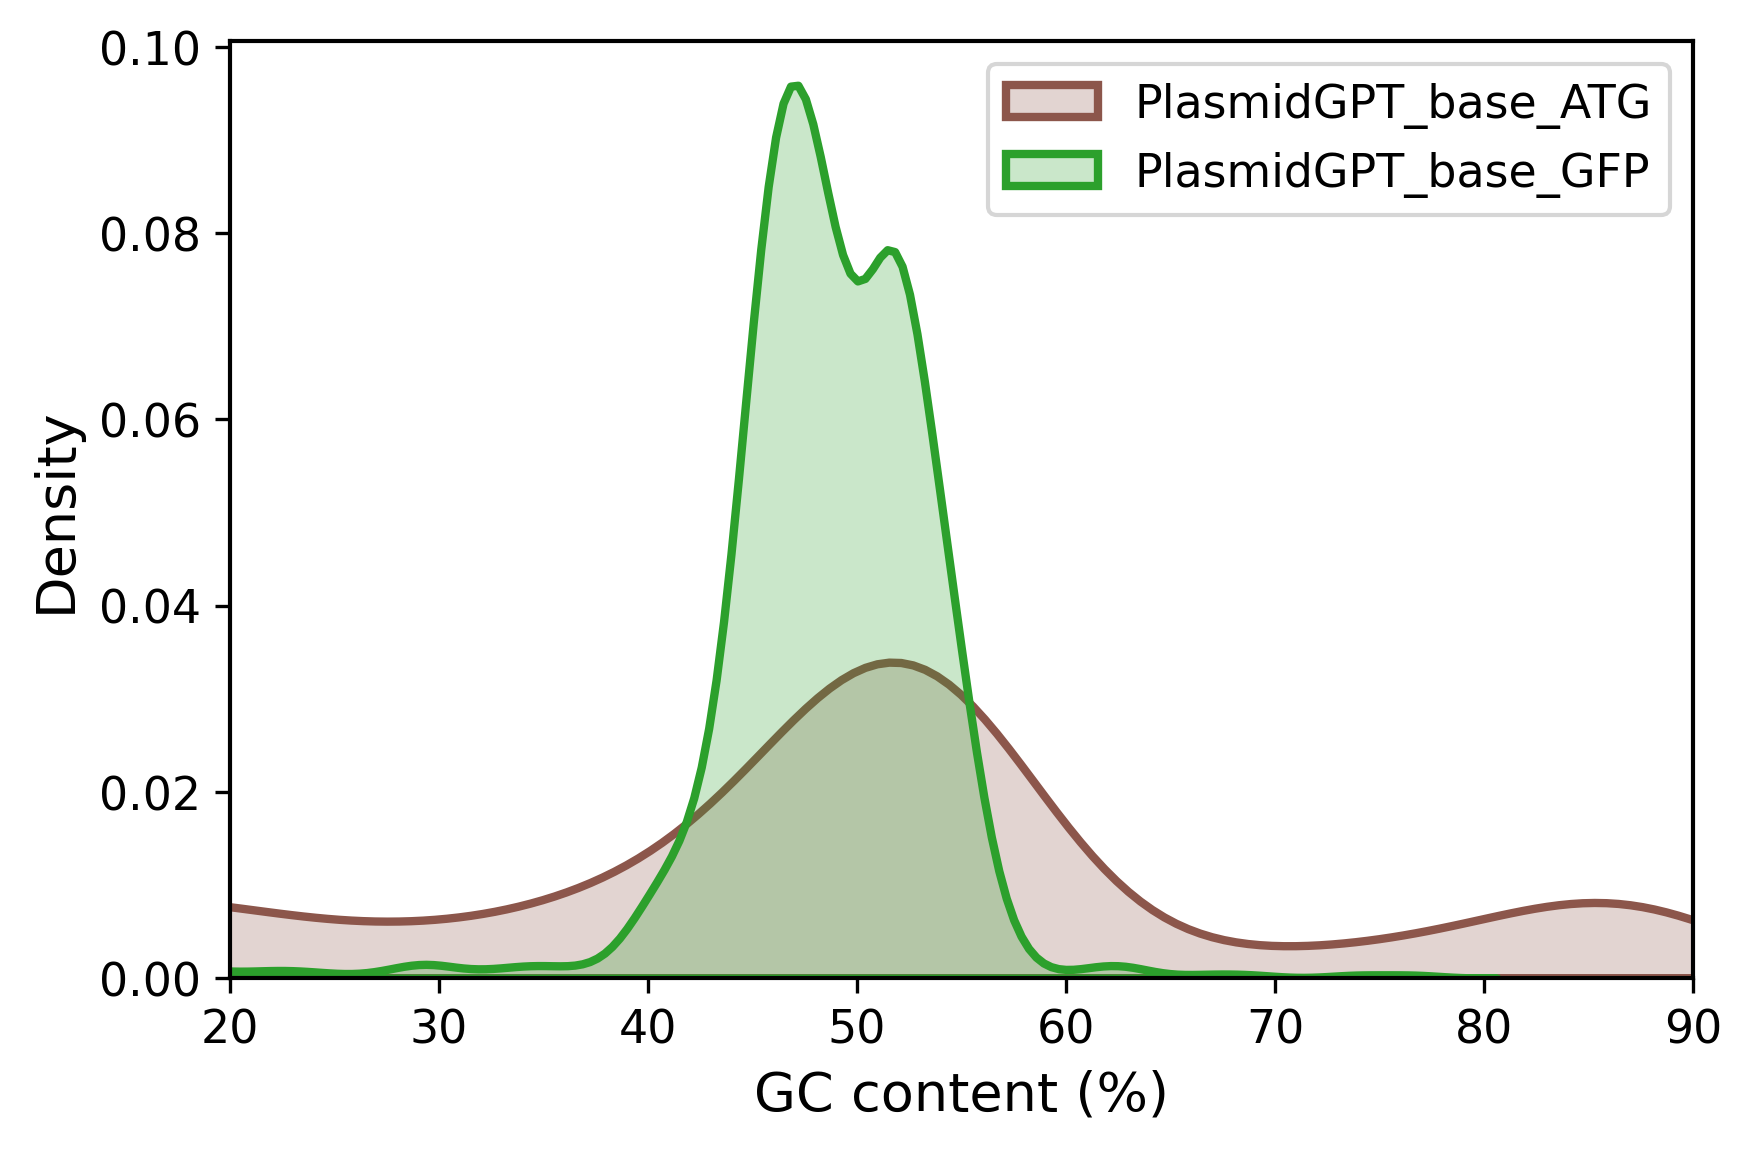

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
for name in ["PlasmidGPT_base_ATG","PlasmidGPT_base_GFP"]:
    sns.kdeplot(
        data=gen_all[gen_all["dataset"]==name],
        x="gc_percent", lw=2, fill=True, alpha=0.25,
        color=palette[name], label=name, ax=ax
    )
ax.set_xlabel("GC content (%)"); ax.set_ylabel("Density")
ax.set_xlim(20,90); ax.legend(loc="upper right", frameon=True)
fig.tight_layout(); plt.show()
# Optional:
# fig.savefig("figures/gc_base_ATG_vs_GFP.pdf", bbox_inches="tight")


In [16]:
fig.savefig("figures/gc_base_ATG_vs_GFP.pdf", bbox_inches="tight")